# Online Shopper Conversion: Data Quality and EDA

This notebook checks whether the session data are trustworthy enough for analysis, then explores the behaviours most associated with purchase conversion. The modelling workflow is kept in the companion notebook, `02_modelling_and_evaluation.ipynb`.

**Business question:** Which browsing patterns distinguish purchase from non-purchase sessions, and what do those patterns imply for later modelling?

## Setup and data

The loader checks the notebook folder and a `data/` subfolder. Set `SAVE_FIGURES = False` when figures should display without being written to disk.

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SAVE_FIGURES = True
FIGURE_DIR = Path("outputs/figures")
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def finish_figure(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()

In [4]:
candidate_paths = [
    Path("online_shoppers_intention.csv"),
    Path("data/online_shoppers_intention.csv"),
]

csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "Could not find online_shoppers_intention.csv. "
        "Download the official UCI file and place it beside this notebook or inside a data/ folder."
    )

df_raw = pd.read_csv(csv_path)
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
display(df_raw.head())

Shape: 12,330 rows × 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


## Data quality

The checks below cover structure, missingness, exact duplicates, logical ranges and data types. Exact duplicates are removed before modelling because identical rows split across train and test sets could make evaluation look slightly better than it really is. This is a conservative choice, not proof that every duplicate is an error.

In [6]:
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_n": df_raw.isna().sum(),
    "missing_pct": df_raw.isna().mean() * 100,
    "unique_n": df_raw.nunique(dropna=False)
})
display(audit)

,dtype,missing_n,missing_pct,unique_n
Administrative,int64,0,0.0000,27
Administrative_Duration,float64,0,0.0000,3335
Informational,int64,0,0.0000,17
Informational_Duration,float64,0,0.0000,1258
ProductRelated,int64,0,0.0000,311
ProductRelated_Duration,float64,0,0.0000,9551
BounceRates,float64,0,0.0000,1872
ExitRates,float64,0,0.0000,4777
PageValues,float64,0,0.0000,2704
SpecialDay,float64,0,0.0000,6


In [7]:
print("Dataset information")
print("-" * 60)
df_raw.info()

Dataset information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  


In [8]:
numeric_summary = df_raw.select_dtypes(include=np.number).describe().T
numeric_summary["median"] = df_raw.select_dtypes(include=np.number).median()
numeric_summary["skew"] = df_raw.select_dtypes(include=np.number).skew()
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,median,skew
Administrative,"12,330.0000",2.3152,3.3218,0.0000,0.0000,1.0000,4.0000,27.0000,1.0000,1.9604
Administrative_Duration,"12,330.0000",80.8186,176.7791,0.0000,0.0000,7.5000,93.2562,"3,398.7500",7.5000,5.6157
Informational,"12,330.0000",0.5036,1.2702,0.0000,0.0000,0.0000,0.0000,24.0000,0.0000,4.0365
Informational_Duration,"12,330.0000",34.4724,140.7493,0.0000,0.0000,0.0000,0.0000,"2,549.3750",0.0000,7.5792
ProductRelated,"12,330.0000",31.7315,44.4755,0.0000,7.0000,18.0000,38.0000,705.0000,18.0000,4.3415
ProductRelated_Duration,"12,330.0000","1,194.7462","1,913.6693",0.0000,184.1375,598.9369,"1,464.1572","63,973.5222",598.9369,7.2632
BounceRates,"12,330.0000",0.0222,0.0485,0.0000,0.0000,0.0031,0.0168,0.2000,0.0031,2.9479
ExitRates,"12,330.0000",0.0431,0.0486,0.0000,0.0143,0.0252,0.0500,0.2000,0.0252,2.1488
PageValues,"12,330.0000",5.8893,18.5684,0.0000,0.0000,0.0000,0.0000,361.7637,0.0000,6.3830
SpecialDay,"12,330.0000",0.0614,0.1989,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,3.3027


In [9]:
categorical_columns_initial = df_raw.select_dtypes(exclude=np.number).columns

for column in categorical_columns_initial:
    print(f"\n{column}")
    display(
        df_raw[column]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
        .assign(percent=lambda x: 100 * x["count"] / len(df_raw))
    )


Month


,count,percent
Month,,
May,3364,27.2830
Nov,2998,24.3147
Mar,1907,15.4663
Dec,1727,14.0065
Oct,549,4.4526
Sep,448,3.6334
Aug,433,3.5118
Jul,432,3.5036
June,288,2.3358



VisitorType


,count,percent
VisitorType,,
Returning_Visitor,10551,85.5718
New_Visitor,1694,13.7388
Other,85,0.6894



Weekend


,count,percent
Weekend,,
False,9462,76.7397
True,2868,23.2603



Revenue


,count,percent
Revenue,,
False,10422,84.5255
True,1908,15.4745


In [10]:
duplicate_n = df_raw.duplicated().sum()
duplicate_pct = 100 * duplicate_n / len(df_raw)

print(f"Exact duplicate rows: {duplicate_n:,} ({duplicate_pct:.2f}%)")

if duplicate_n:
    display(
        df_raw[df_raw.duplicated(keep=False)]
        .sort_values(df_raw.columns.tolist())
        .head(20)
    )

Exact duplicate rows: 125 (1.01%)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Dec,1,1,4,1,Returning_Visitor,True,False


In [11]:
df = df_raw.drop_duplicates().reset_index(drop=True).copy()

print(f"Rows before cleaning: {len(df_raw):,}")
print(f"Rows after duplicate removal: {len(df):,}")
print(f"Rows removed: {len(df_raw) - len(df):,}")

Rows before cleaning: 12,330
Rows after duplicate removal: 12,205
Rows removed: 125


In [12]:
# Logical range checks based on feature definitions
range_checks = pd.Series({
    "BounceRates outside [0, 1]": (~df["BounceRates"].between(0, 1)).sum(),
    "ExitRates outside [0, 1]": (~df["ExitRates"].between(0, 1)).sum(),
    "SpecialDay outside [0, 1]": (~df["SpecialDay"].between(0, 1)).sum(),
    "Negative duration values": (
        df[[
            "Administrative_Duration",
            "Informational_Duration",
            "ProductRelated_Duration"
        ]] < 0
    ).any(axis=1).sum(),
    "Negative page counts": (
        df[["Administrative", "Informational", "ProductRelated"]] < 0
    ).any(axis=1).sum(),
})
display(range_checks.rename("violations").to_frame())

,violations
"BounceRates outside [0, 1]",0
"ExitRates outside [0, 1]",0
"SpecialDay outside [0, 1]",0
Negative duration values,0
Negative page counts,0


**Cleaning decisions**

The supplied data contain no missing values, although the modelling pipeline still includes imputation for future robustness. `OperatingSystems`, `Browser`, `Region` and `TrafficType` are integer-coded categories rather than measured quantities, so they should be one-hot encoded instead of treated as continuous numbers. `Weekend` is also categorical.

## Exploratory analysis

The analysis focuses on class balance, behavioural differences by outcome, conversion across useful segments, skewness and correlation. Charts are saved to `outputs/figures/` as well as displayed in the notebook.

,sessions,share
Revenue,,
False,10297,0.8437
True,1908,0.1563


Overall conversion rate: 15.63%


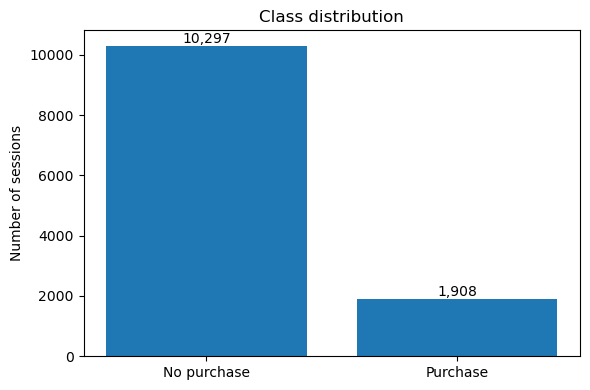

In [15]:
conversion_count = df["Revenue"].value_counts().sort_index()
conversion_rate = df["Revenue"].mean()

display(pd.DataFrame({
    "sessions": conversion_count,
    "share": conversion_count / len(df)
}))

print(f"Overall conversion rate: {conversion_rate:.2%}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No purchase", "Purchase"], conversion_count.values)
ax.set_title("Class distribution")
ax.set_ylabel("Number of sessions")
for i, value in enumerate(conversion_count.values):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")
finish_figure(fig, "01_class_distribution.png")

The minority purchase class makes up only a modest share of sessions. This confirms that stratified splitting and precision-recall metrics are necessary.

**Executive data snapshot**

The dataset is useful for modelling purchase intent, but its business boundaries are important:

- _Conversion is uncommon_: so a model must do more than predict “no purchase” for everyone.
- _Sessions are not customers_: Repeat visitors cannot be linked across visits.
- _Revenue is binary_: The dataset cannot distinguish a 20-dollar order from a 500-dollar order.
- _Feature timing is uncertain_: Some variables may be updated throughout the session, while `PageValues` is especially close to the final commercial outcome.

This means that **the model can help prioritise sessions for testing and resource allocation. It cannot estimate incremental revenue without campaign-cost, order-value and experimental data.**

In [18]:
business_snapshot = pd.DataFrame({
    "Metric": [
        "Sessions analysed",
        "Purchase sessions",
        "Non-purchase sessions",
        "Observed conversion rate",
        "Available predictors",
        "Customer identifier available?",
        "Order value available?"
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['Revenue'].sum():,}",
        f"{(~df['Revenue']).sum():,}",
        f"{df['Revenue'].mean():.1%}",
        f"{df.shape[1]-1}",
        "No",
        "No"
    ]
})
display(business_snapshot)

,Metric,Value
0,Sessions analysed,"12,205"
1,Purchase sessions,"1,908"
2,Non-purchase sessions,"10,297"
3,Observed conversion rate,15.6%
4,Available predictors,17
5,Customer identifier available?,No
6,Order value available?,No


In [19]:
numeric_columns = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]

summary_by_target = (
    df.groupby("Revenue")[numeric_columns]
    .agg(["mean", "median"])
    .T
)
display(summary_by_target)

Revenue                             False      True 
Administrative          mean       2.1434     3.3936
                        median     1.0000     2.0000
Administrative_Duration mean      74.6353   119.4832
                        median     0.0000    52.3667
Informational           mean       0.4573     0.7862
                        median     0.0000     0.0000
Informational_Duration  mean      30.6033    57.6114
                        median     0.0000     0.0000
ProductRelated          mean      29.0504    48.2102
                        median    16.0000    29.0000
ProductRelated_Duration mean   1,082.9769 1,876.2096
                        median   526.0000 1,109.9062
BounceRates             mean       0.0232     0.0051
                        median     0.0039     0.0000
ExitRates               mean       0.0455     0.0196
                        median     0.0284     0.0160
PageValues              mean       2.0000    27.2645
                        median     0.0000    16.7581
SpecialDay              mean       0.0691     0.0232
                        median     0.0000     0.0000

In [20]:
# Median comparison is useful because many behavioural variables are right-skewed.
median_comparison = df.groupby("Revenue")[numeric_columns].median().T
median_comparison.columns = ["No purchase", "Purchase"]
median_comparison["Purchase / no-purchase ratio"] = (
    median_comparison["Purchase"] /
    median_comparison["No purchase"].replace(0, np.nan)
)
display(median_comparison.sort_values("Purchase / no-purchase ratio", ascending=False))

,No purchase,Purchase,Purchase / no-purchase ratio
ProductRelated_Duration,526.0000,"1,109.9062",2.1101
Administrative,1.0000,2.0000,2.0000
ProductRelated,16.0000,29.0000,1.8125
ExitRates,0.0284,0.0160,0.5637
BounceRates,0.0039,0.0000,0.0000
Administrative_Duration,0.0000,52.3667,NaN
Informational,0.0000,0.0000,NaN
Informational_Duration,0.0000,0.0000,NaN
PageValues,0.0000,16.7581,NaN
SpecialDay,0.0000,0.0000,NaN


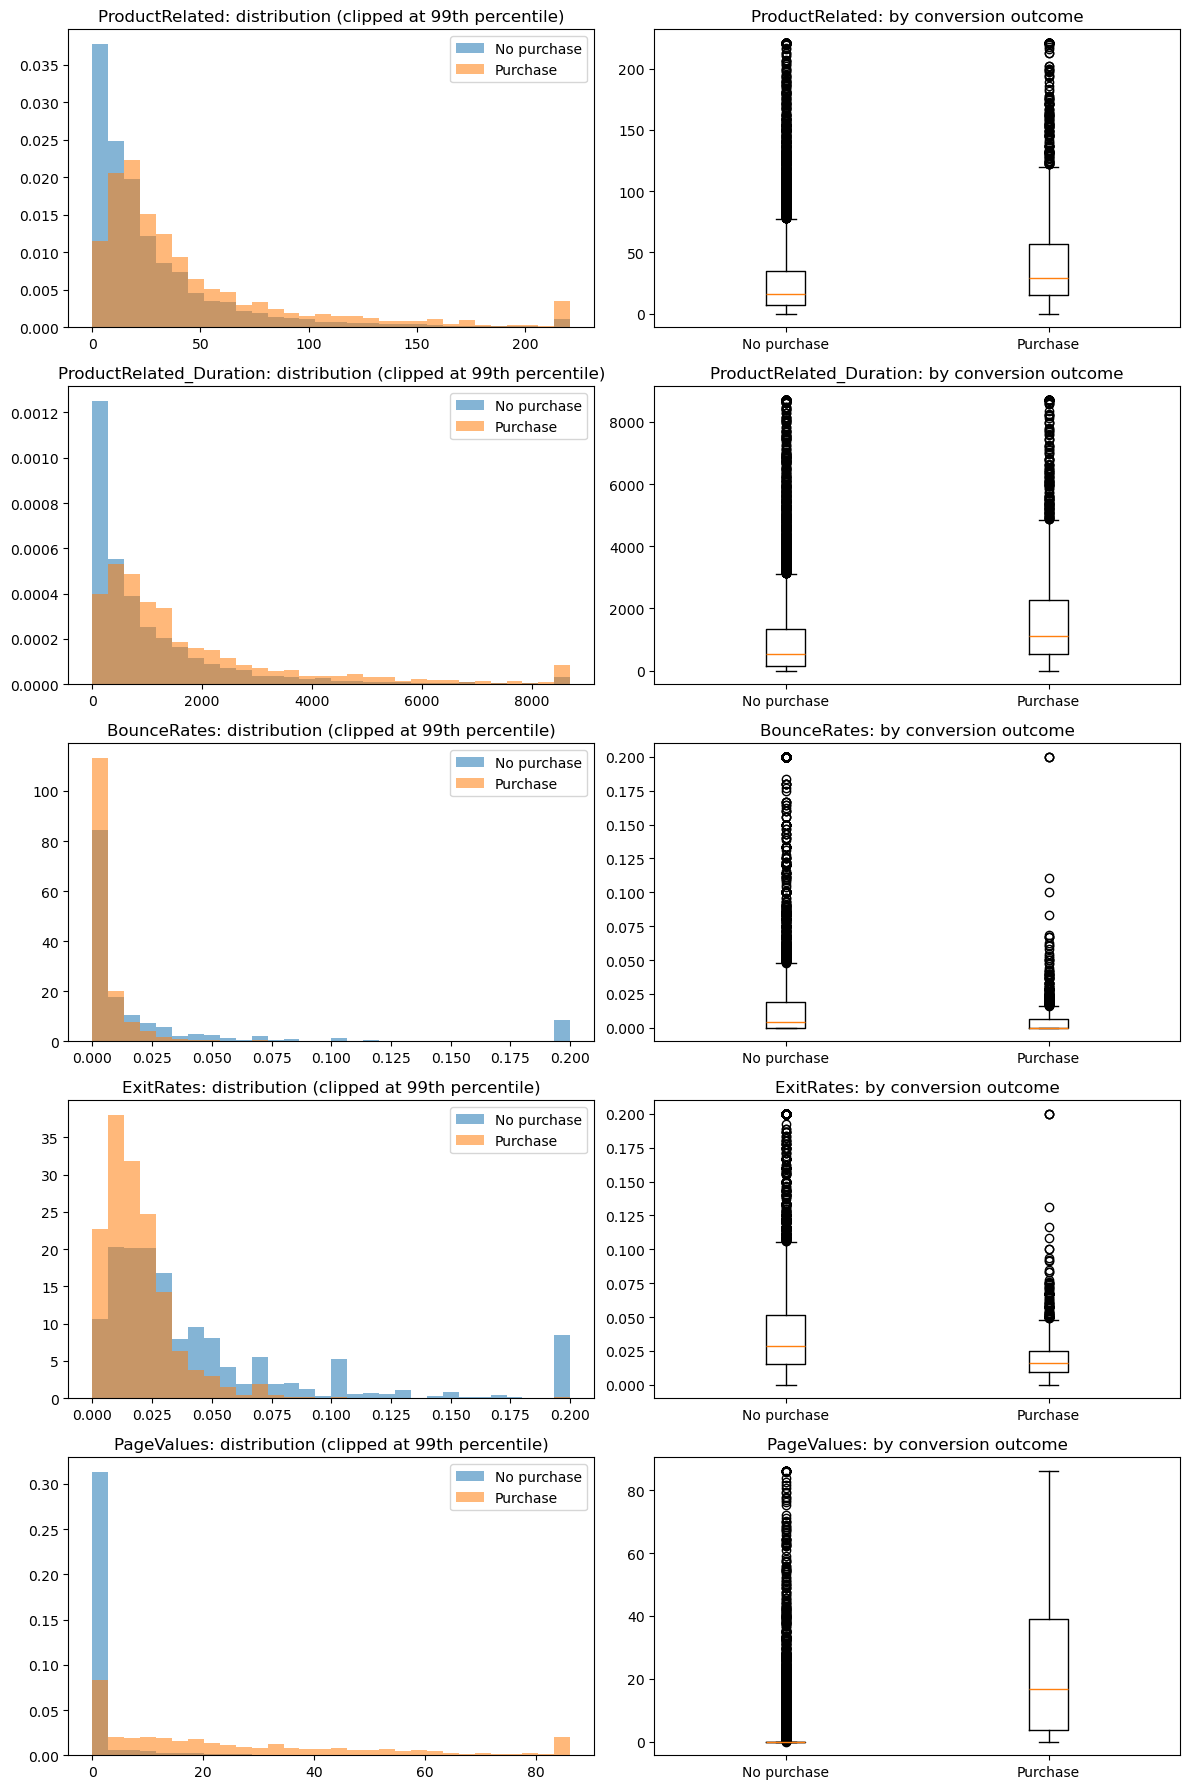

In [21]:
plot_columns = [
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues"
]

fig, axes = plt.subplots(len(plot_columns), 2, figsize=(12, 18))

for row, column in enumerate(plot_columns):
    # left: histogram
    upper = df[column].quantile(0.99)
    for outcome, label in [(False, "No purchase"), (True, "Purchase")]:
        values = df.loc[df["Revenue"] == outcome, column].clip(upper=upper)
        axes[row, 0].hist(values, bins=30, alpha=0.55, density=True, label=label)
    axes[row, 0].set_title(f"{column}: distribution (clipped at 99th percentile)")
    axes[row, 0].legend()

    # right: boxplot
    no_purchase = df.loc[~df["Revenue"], column].clip(upper=upper)
    purchase = df.loc[df["Revenue"], column].clip(upper=upper)
    axes[row, 1].boxplot([no_purchase, purchase], tick_labels=["No purchase", "Purchase"])
    axes[row, 1].set_title(f"{column}: by conversion outcome")

finish_figure(fig, "02_behavioural_distributions.png")

Clipping in the charts is for visual purposes only. The original values remain unchanged for modelling. Tree models naturally handle nonlinearities and extreme values, while scaled logistic regression reduces sensitivity to scale differences.

In [23]:
def conversion_table(data, column, min_sessions=1):
    table = (
        data.groupby(column, observed=False)["Revenue"]
        .agg(sessions="size", purchases="sum", conversion_rate="mean")
        .query("sessions >= @min_sessions")
        .sort_values("conversion_rate", ascending=False)
    )
    return table

for column in ["Month", "VisitorType", "Weekend"]:
    print(f"\nConversion by {column}")
    display(conversion_table(df, column))


Conversion by Month


,sessions,purchases,conversion_rate
Month,,,
Nov,2982,760,0.2549
Oct,549,115,0.2095
Sep,448,86,0.1920
Aug,433,76,0.1755
Jul,432,66,0.1528
Dec,1706,216,0.1266
May,3329,365,0.1096
Mar,1860,192,0.1032
June,285,29,0.1018



Conversion by VisitorType


,sessions,purchases,conversion_rate
VisitorType,,,
New_Visitor,1693,422,0.2493
Other,81,16,0.1975
Returning_Visitor,10431,1470,0.1409



Conversion by Weekend


,sessions,purchases,conversion_rate
Weekend,,,
True,2859,499,0.1745
False,9346,1409,0.1508


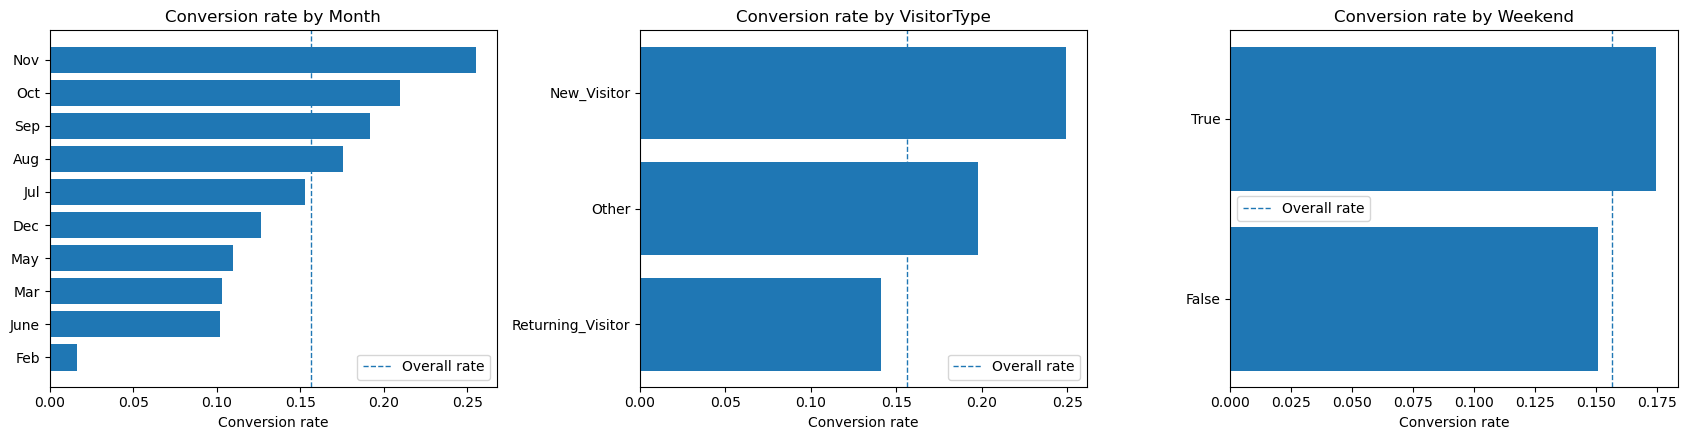

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, column in zip(axes, ["Month", "VisitorType", "Weekend"]):
    table = conversion_table(df, column).sort_values("conversion_rate")
    ax.barh(table.index.astype(str), table["conversion_rate"])
    ax.axvline(conversion_rate, linestyle="--", linewidth=1, label="Overall rate")
    ax.set_title(f"Conversion rate by {column}")
    ax.set_xlabel("Conversion rate")
    ax.legend()

finish_figure(fig, "03_conversion_rates_by_segment.png")

In [25]:
coded_categories = ["OperatingSystems", "Browser", "Region", "TrafficType"]

for column in coded_categories:
    print(f"\nHighest-volume {column} categories")
    table = conversion_table(df, column, min_sessions=30)
    display(table.sort_values("sessions", ascending=False).head(15))


Highest-volume OperatingSystems categories


,sessions,purchases,conversion_rate
OperatingSystems,,,
2,6541,1155,0.1766
1,2549,379,0.1487
3,2530,268,0.1059
4,478,85,0.1778
8,75,17,0.2267



Highest-volume Browser categories


,sessions,purchases,conversion_rate
Browser,,,
2,7883,1223,0.1551
1,2427,365,0.1504
4,731,130,0.1778
5,465,86,0.1849
6,174,20,0.1149
10,163,32,0.1963
8,135,21,0.1556
3,105,5,0.0476
13,56,16,0.2857



Highest-volume Region categories


,sessions,purchases,conversion_rate
Region,,,
1,4714,771,0.1636
3,2379,349,0.1467
4,1171,175,0.1494
2,1128,188,0.1667
6,801,112,0.1398
7,758,119,0.1570
9,505,86,0.1703
8,431,56,0.1299
5,318,52,0.1635



Highest-volume TrafficType categories


,sessions,purchases,conversion_rate
TrafficType,,,
2,3911,847,0.2166
1,2388,262,0.1097
3,2013,180,0.0894
4,1066,165,0.1548
13,728,43,0.0591
10,450,90,0.2000
6,443,53,0.1196
8,343,95,0.2770
5,260,56,0.2154


Category-level conversion rates should not be interpreted causally. Small categories may show unstable rates, so session volume is displayed alongside conversion.

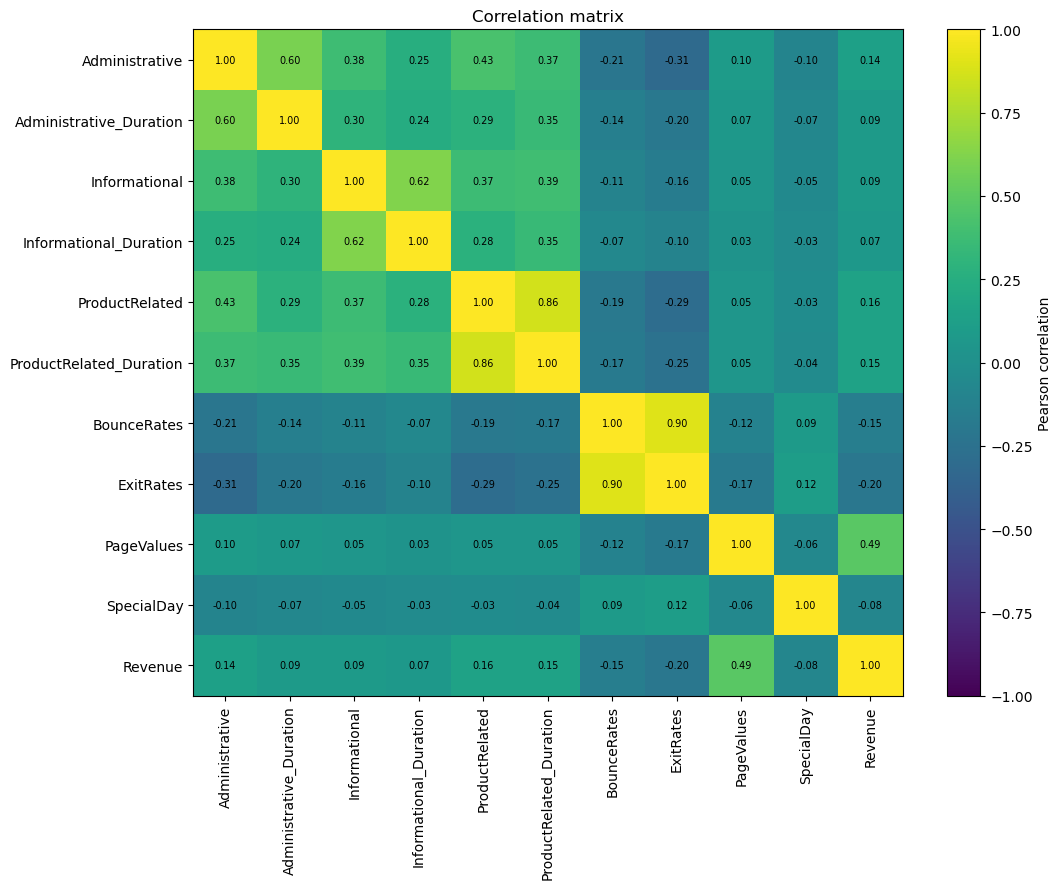

In [27]:
corr = df[numeric_columns + ["Revenue"]].astype(float).corr()

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr, aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation matrix")
fig.colorbar(image, ax=ax, label="Pearson correlation")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

finish_figure(fig, "04_correlation_matrix.png")

In [28]:
target_correlations = (
    corr["Revenue"]
    .drop("Revenue")
    .sort_values(key=abs, ascending=False)
    .rename("correlation_with_revenue")
)
display(target_correlations.to_frame())

,correlation_with_revenue
PageValues,0.4919
ExitRates,-0.2043
ProductRelated,0.1560
ProductRelated_Duration,0.1501
BounceRates,-0.1451
Administrative,0.1363
Informational,0.0936
Administrative_Duration,0.0918
SpecialDay,-0.0836
Informational_Duration,0.0694


## What the patterns suggest

Purchase sessions generally show deeper product exploration, longer product-related duration, lower bounce and exit behaviour, and much higher `PageValues`. Conversion also varies by month and visitor type.

These patterns suggest three practical session states:

1. **Low-engagement exits:** likely acquisition or landing-page problems rather than a simple need for discounts.
2. **Active product exploration:** the most plausible group for low-cost assistance, comparison help or reassurance.
3. **Late-stage commercial intent:** easy to rank, but potentially poor targets for heavy incentives because many may purchase anyway.

The findings are predictive, not causal. They should become testable hypotheses in later experiments rather than claims that a particular behaviour causes conversion.